# SUPPORT2 Dataset: Data Cleaning & Preparation
**AAI-500 Applied Statistics for AI | Final Team Project**

---

## Notebook Objectives

This notebook covers the **Data Cleaning & Preparation** phase of the project pipeline:

1. Initial data inspection and profiling
1. Column renames per PEP-8
1. Engineering the binary target variable (`death_180d`)
1. Data type casting and ordinal/nominal encoding
1. Missing data analysis and imputation
1. Dropping unused columns
1. Documenting target / feature / outcome 
1. Export of the cleaned dataset for EDA and modeling

---
## Section 0: Setup & Imports

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


sys.path.append("../../utils")
from dataset import get_project_root, load_csv

warnings.filterwarnings("ignore")

current = Path.cwd().resolve()

while current != current.parent:
    if (current / ".git").exists() or (current / "pyproject.toml").exists():
        project_root = current
        break
    current = current.parent

PROJ_ROOT = get_project_root()
OUTPUT_PATH = PROJ_ROOT / "data" / "support2_cleaned.csv"
print(f"Output path  : {OUTPUT_PATH}")

Output path  : C:\Users\mwee\Documents\USD-AAI\aai-500\final\usd-aai-500-final\data\support2_cleaned.csv


---
## Section 1: Load Data & Initial Inspection

In [2]:
df_raw = load_csv("support2_raw_complete.csv")
print(f"Shape: {df_raw.shape[0]:,} rows  x  {df_raw.shape[1]} columns")
df_raw.head()

Shape: 9,105 rows  x  48 columns


,id,age,death,sex,hospdead,slos,d.time,dzgroup,dzclass,num.co,...,crea,sod,ph,glucose,bun,urine,adlp,adls,sfdm2,adlsc
0,1,62.84998,0,male,0,5,2029,Lung Cancer,Cancer,0,...,1.199951,141.0,7.459961,NaN,NaN,NaN,7.0,7.0,NaN,7.0
1,2,60.33899,1,female,1,4,4,Cirrhosis,COPD/CHF/Cirrhosis,2,...,5.500000,132.0,7.250000,NaN,NaN,NaN,NaN,1.0,<2 mo. follow-up,1.0
2,3,52.74698,1,female,0,17,47,Cirrhosis,COPD/CHF/Cirrhosis,2,...,2.000000,134.0,7.459961,NaN,NaN,NaN,1.0,0.0,<2 mo. follow-up,0.0
3,4,42.38498,1,female,0,3,133,Lung Cancer,Cancer,2,...,0.799927,139.0,NaN,NaN,NaN,NaN,0.0,0.0,no(M2 and SIP pres),0.0
4,5,79.88495,0,female,0,16,2029,ARF/MOSF w/Sepsis,ARF/MOSF,1,...,0.799927,143.0,7.509766,NaN,NaN,NaN,NaN,2.0,no(M2 and SIP pres),2.0


In [3]:
df_raw.info(verbose=True, show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 9105 entries, 0 to 9104
Data columns (total 48 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        9105 non-null   int64  
 1   age       9105 non-null   float64
 2   death     9105 non-null   int64  
 3   sex       9105 non-null   str    
 4   hospdead  9105 non-null   int64  
 5   slos      9105 non-null   int64  
 6   d.time    9105 non-null   int64  
 7   dzgroup   9105 non-null   str    
 8   dzclass   9105 non-null   str    
 9   num.co    9105 non-null   int64  
 10  edu       7471 non-null   float64
 11  income    6123 non-null   str    
 12  scoma     9104 non-null   float64
 13  charges   8933 non-null   float64
 14  totcst    8217 non-null   float64
 15  totmcst   5630 non-null   float64
 16  avtisst   9023 non-null   float64
 17  race      9063 non-null   str    
 18  sps       9104 non-null   float64
 19  aps       9104 non-null   float64
 20  surv2m    9104 non-null   float64
 21  su

In [4]:
int_cols = df_raw.select_dtypes(include="int64").columns
binary_cols = [
    c
    for c in int_cols
    if df_raw[c].nunique() == 2 and set(df_raw[c].unique()) == {0, 1}
]
print("===========Binary Columns==========")
print(binary_cols)


===========Binary Columns==========
['death', 'hospdead', 'diabetes', 'dementia']


### 1.1 Descriptive Statistics

In [5]:
desc = df_raw.describe().T
desc.columns = [
    "Count",
    "Mean",
    "Std Dev",
    "Min",
    "Q1 (25%)",
    "Median (50%)",
    "Q3 (75%)",
    "Max",
]
desc

,Count,Mean,Std Dev,Min,Q1 (25%),Median (50%),Q3 (75%),Max
id,9105.0,4553.000000,2628.531434,1.000000,2277.000000,4553.000000,6829.000000,9.105000e+03
age,9105.0,62.650823,15.593710,18.041990,52.797000,64.856990,73.998960,1.018480e+02
death,9105.0,0.681054,0.466094,0.000000,0.000000,1.000000,1.000000,1.000000e+00
hospdead,9105.0,0.259198,0.438219,0.000000,0.000000,0.000000,1.000000,1.000000e+00
slos,9105.0,17.863042,22.006440,3.000000,6.000000,11.000000,20.000000,3.430000e+02
d.time,9105.0,478.449863,560.383272,3.000000,26.000000,233.000000,761.000000,2.029000e+03
num.co,9105.0,1.868644,1.344409,0.000000,1.000000,2.000000,3.000000,9.000000e+00
edu,7471.0,11.747691,3.447743,0.000000,10.000000,12.000000,14.000000,3.100000e+01
scoma,9104.0,12.058546,24.636694,0.000000,0.000000,0.000000,9.000000,1.000000e+02
charges,8933.0,59995.787811,102648.778198,1169.000000,9740.000000,25024.000000,64598.000000,1.435423e+06


---
## Section 2: Column Renaming

Rename some columsn to follow PEP-8 standard

In [6]:
rename_map = {
    "d.time": "d_time",
    "num.co": "num_co",
}
df = df_raw.rename(columns=rename_map).copy()

print("Column renames applied:")
for old, new in rename_map.items():
    print(f"  {old!r}  ->  {new!r}")
print(f"\nTotal columns: {len(df.columns)}")

Column renames applied:
  'd.time'  ->  'd_time'
  'num.co'  ->  'num_co'

Total columns: 48


---
## Section 3: Target Variable

**Did the patient die within 180 days of study?**

To answer this we look at two fields: 
- `death`:  whether the patient ever died during 180 days (1 = yes, 0 = no)
- `d_time`:  days of follow-up (how long they were observed). If this number is greater than 180 days of the trial, that means they survived the trial

death_180d (1 = yes, 0 = no) = {death=1 AND d_time <= 180}

Notice the AND conditional because the patient must've died within the 180 days to satisfy our target. 
We then use **death_180d** for binary classification


In [7]:
df["death_180d"] = ((df["death"] == 1) & (df["d_time"] <= 180)).astype(int)

counts = df["death_180d"].value_counts()
rel_freqs = df["death_180d"].value_counts(normalize=True)

summary = pd.DataFrame(
    {
        "Outcome": ["Survived >= 180 days (0)", "Died within 180 days (1)"],
        "Frequency": counts.values,
        "Relative Frequency": rel_freqs,
        "Percentage (%)": (rel_freqs.values * 100),
    }
)
print(summary.to_string(index=False))
print(f"\nClass imbalance ratio (survived: died) = {counts[0] / counts[1]:.2f} : 1")

                 Outcome  Frequency  Relative Frequency  Percentage (%)
Survived >= 180 days (0)       4840            0.531576       53.157606
Died within 180 days (1)       4265            0.468424       46.842394

Class imbalance ratio (survived: died) = 1.13 : 1


---
## Section 4: Data Type Casting (into Pandas Type)

Correct data types are essential for proper computing and modeling.
We apply three categories of correction. Casting to Int8 also handles NaN gracefully:

1. **Binary integer columns** -> `Int8` (nullable integer; memory-efficient)
2. **Nominal categorical columns** -> unordered `pd.Categorical`
3. **Ordinal categorical columns** -> ordered `pd.Categorical` for proper sorting and comparision

**`income` ordering (ascending socioeconomic status):**
`under $11k` < `$11-$25k` < `$25-$50k` < `>$50k`

**`sfdm2` ordering (best functional status → worst):**
`no disability` < `moderate ADL impairment` < `severe SIP impairment` < `coma/intubated` < `died before 2-month interview`

In [8]:
# Binary columns -> nullable Int8
binary_cols = ["death", "hospdead", "diabetes", "dementia"]
for col in binary_cols:
    df[col] = df[col].astype("Int8")

######  8 Catagoricals
# sex = 2 levels
# dzgroup = 5
# dzclass = 4
# race = 5
# income = 4
# ca = 3
# dnr = 3
# sfdm2 = 5
##############

# Nominal (unordered) categoricals
nominal_cats = ["sex", "dzgroup", "dzclass", "race", "ca", "dnr"]
for col in nominal_cats:
    df[col] = df[col].astype("category")

# Ordinal: income (lowest -> highest bracket) as coded in support2_data_dictionary.md
income_order = ["under $11k", "$11-$25k", "$25-$50k", ">$50k"]
df["income"] = pd.Categorical(df["income"], categories=income_order, ordered=True)

# Ordinal: sfdm2 (2-month functional disability; no disability -> died before interview)
# as coded in support2_data_dictionary.md
sfdm2_order = [
    "no(M2 and SIP pres)",  # Level 1 - no moderate/severe disability
    "adl>=4 (>=5 if sur)",  # Level 2 - unable to do 4+ ADL
    "SIP>=30",  # Level 3 - Sickness Impact Profile >= 30
    "Coma or Intub",  # Level 4 - intubated or in coma at 2 months
    "<2 mo. follow-up",  # Level 5 - died before 2-month interview
]
df["sfdm2"] = pd.Categorical(df["sfdm2"], categories=sfdm2_order, ordered=True)

print("Data type corrections applied:\n")
cols_updated = binary_cols + nominal_cats + ["income", "sfdm2"]
print(df[cols_updated].dtypes.to_string())

Data type corrections applied:

death           Int8
hospdead        Int8
diabetes        Int8
dementia        Int8
sex         category
dzgroup     category
dzclass     category
race        category
ca          category
dnr         category
income      category
sfdm2       category


---
## Section 5: Missing Data Analysis

The authors have stated there are a maximum of 5641 N/As. This, along with every other missing data, we must verify and address.


In [9]:
missing_count = df.isnull().sum()
missing_percent = missing_count / len(df) * 100
missing_df = pd.DataFrame(
    {
        "Missing Count": missing_count,
        "Missing %": missing_percent,
    }
).sort_values("Missing Count", ascending=False)

missing_df = missing_df[missing_df["Missing Count"] > 0]

total_cells = df.shape[0] * df.shape[1]
total_missing = int(missing_df["Missing Count"].sum())

print(f"Columns with at least one missing value : {len(missing_df)}")
print(
    f"Total missing cells : {total_missing:,} / {total_cells:,}  ({total_missing / total_cells * 100:.1f}%)\n"
)
print(missing_df.to_string())

# verify maximum missing n/as
max_na = df_raw.isnull().sum().max()
max_na_col = df_raw.isnull().sum().idxmax()
print(f"Max NAs: {max_na} (column: '{max_na_col}')")
assert max_na == 5641, f"Expected 5641, got {max_na}"

Columns with at least one missing value : 33
Total missing cells : 47,110 / 446,145  (10.6%)

         Missing Count  Missing %
adlp              5641  61.954970
urine             4862  53.399231
glucose           4500  49.423394
bun               4352  47.797913
totmcst           3475  38.165843
alb               3372  37.034596
income            2982  32.751236
adls              2867  31.488193
bili              2601  28.566722
pafi              2325  25.535420
ph                2284  25.085118
prg2m             1649  18.110928
edu               1634  17.946183
prg6m             1633  17.935200
sfdm2             1400  15.376167
totcst             888   9.752883
wblc               212   2.328391
charges            172   1.889072
avtisst             82   0.900604
crea                67   0.735859
race                42   0.461285
dnrday              30   0.329489
dnr                 30   0.329489
sps                  1   0.010983
aps                  1   0.010983
sod                  1

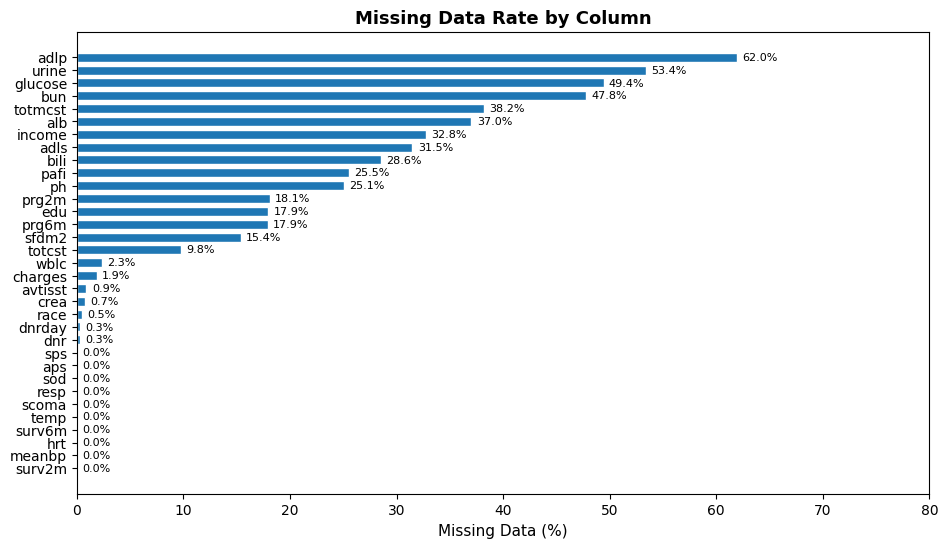

In [10]:
fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.barh(
    missing_df.index[::-1],
    missing_df["Missing %"][::-1],
    edgecolor="white",
    height=0.7,
)


ax.set_xlabel("Missing Data (%)", fontsize=11)
ax.set_title("Missing Data Rate by Column", fontsize=13, fontweight="bold")
ax.set_xlim(0, 80)

for bar, pct in zip(bars, missing_df["Missing %"][::-1]):
    if pct > 0:
        ax.text(
            bar.get_width() + 0.5,
            bar.get_y() + bar.get_height() / 2,
            f"{pct:.1f}%",
            va="center",
            fontsize=8,
        )
plt.show()

### 5.1 Missing Data Decision Table

Here we decide how to tackle missing data. Either drop the column entirely or impute mathematically

For most of our biological features that have missing data, we compute the median. The reason is per Agresti et al (2022), chapter 3, that for right-skewed data, using median instead of mean worse the skewness of the data (push it woard the tail). Looking at section 1, our columns the mean > median, which signals right skewed.



| Column(s) | Decision | Rationale |
|---|---|---|
| `adlp`, `adls` | **Drop** | Superseded by `adlsc` per original authors
| `dnrday` | **Drop** | Do-no-resus day. Useless for our purpose
| `hday` | **Drop** | Day admitted to study. Nothing to do with mortality
| `charges, totcst, totmcst` | **Drop** | Relating to hospital cost, which we won't be studying
| `alb`, `pafi`, `bili`, `crea`, `bun`, `wblc`, `urine` | **imputed values avail** | Per Author's note we have the recommended imputed values
| `ph`, `glucose`, `scoma`, `avtisst`, `edu`, `prg2m`, `prg6m`  | **Sample median** | high missing |
| `surv2m`, `surv6m`, `aps`, | **Sample median** | kept as benchmark columns |
| `meanbp`, `hrt`, `resp`, `temp`, `sod` | **Sample median** | few missing |
| `charges`, `totcst` |  **Sample median** | Retained for future cost analysis |
| `totmcst` | **Sample median** | Retained for future cost analysis; many missing values and will be difficult to impute. Contains negative values (balances) |
| `race`, `income`, `sfdm2`, `dnr` | **Mode imputation** | Most frequent category as best single-value estimate for categoricals |
| `sps` | **Drop** | We're choosing to drop this because this is computed by the Paper's authors. It's derived from the same lab values already in the dataset. Including it would mean our model is learning from a weighted combination of features it can already see directly |

#### Benchmark Columns (kept but will be excluded from death_180d model features)

| Column | Role | Notes |
|---|---|---|
| `surv2m`, `surv6m` | SUPPORT model predictions | will be compared against our model |
| `aps` | APACHE III severity score | Independent benchmark system widely used in critical care |
| `sps` | SUPPORT physiology sub-score | Component of the SUPPORT model ?? |
| `prg2m`, `prg6m` | Physician survival estimates | ML vs. clinician judgment comparison |
| `dnr` | DNR order status | **Should not use as predictor feature as it's reflects human behavior rather than biological factors** |

---
## Section 6: Feature Pruning

We remove features not used in our analysis:

In [11]:
cols_to_drop = ["adlp", "adls", "dnrday", "sps", "hday", "charges", "totcst", "totmcst"]

df.drop(columns=cols_to_drop, inplace=True, errors="ignore")
print(f"Dropped  : {len(cols_to_drop)} columns")
print(f"Remaining: {df.shape[0]:,} rows  x  {df.shape[1]} columns")
print(f"Remaining columns ({df.shape[1]}):")
print(list(df.columns))

Dropped  : 8 columns
Remaining: 9,105 rows  x  41 columns
Remaining columns (41):
['id', 'age', 'death', 'sex', 'hospdead', 'slos', 'd_time', 'dzgroup', 'dzclass', 'num_co', 'edu', 'income', 'scoma', 'avtisst', 'race', 'aps', 'surv2m', 'surv6m', 'diabetes', 'dementia', 'ca', 'prg2m', 'prg6m', 'dnr', 'meanbp', 'wblc', 'hrt', 'resp', 'temp', 'pafi', 'alb', 'bili', 'crea', 'sod', 'ph', 'glucose', 'bun', 'urine', 'sfdm2', 'adlsc', 'death_180d']


---
## Section 7: Missing Data Imputation

The original SUPPORT study authors (Harrell, 2022) provide clinically validated
**normal fill-in values** for seven physiological variables (see docs/support2_dataset_description.md).
We will use this for imputation

| Variable | Normal Fill | Meaning |
|---|---|---|
| `alb`   | 3.5   | Serum albumin - liver / nutrition |
| `pafi`  | 333.3 | PaO2/FiO2 ratio - oxygen level|
| `bili`  | 1.01  | Bilirubin - liver function |
| `crea`  | 1.01  | Creatinine - renal function |
| `bun`   | 6.51  | BUN - normal renal function |
| `wblc`  | 9.0   | WBC count - immune status |
| `urine` | 2502  | Urine output - renal output |

In [12]:
DOMAIN_FILL = {
    "alb": 3.5,
    "pafi": 333.3,
    "bili": 1.01,
    "crea": 1.01,
    "bun": 6.51,
    "wblc": 9.0,
    "urine": 2502.0,
}

imputation_log = []

for k, v in DOMAIN_FILL.items():
    n_missing = int(df[k].isnull().sum())
    if n_missing > 0:
        df[k] = df[k].fillna(v)
        imputation_log.append(
            {
                "Column": k,
                "Strategy": "Domain Fill",
                "Fill Value": v,
                "Cells Filled": n_missing,
            }
        )

MEDIAN_COLS = [
    "meanbp",
    "hrt",
    "resp",
    "temp",
    "sod",
    "ph",
    "glucose",
    "scoma",
    "avtisst",
    "edu",
    "surv2m",
    "surv6m",
    "aps",
    "prg2m",
    "prg6m",
]
for k in MEDIAN_COLS:
    n_missing = int(df[k].isnull().sum())
    if n_missing > 0:
        med = float(df[k].median())
        df[k] = df[k].fillna(med)
        imputation_log.append(
            {
                "Column": k,
                "Strategy": "Sample Median",
                "Fill Value": round(med, 4),
                "Cells Filled": n_missing,
            }
        )

MODE_COLS = ["race", "income", "sfdm2", "dnr"]

for k in MODE_COLS:
    n_missing = int(df[k].isnull().sum())
    if n_missing > 0:
        mode_val = df[k].mode()[0]
        df[k] = df[k].fillna(mode_val)
        imputation_log.append(
            {
                "Column": k,
                "Strategy": "Sample Mode",
                "Fill Value": str(mode_val),
                "Cells Filled": n_missing,
            }
        )

log_df = pd.DataFrame(imputation_log)
print("Imputation Summary:")
print(log_df.to_string(index=False))
print(f"Total cells imputed: {log_df.get('Cells Filled', np.array([])).sum():,}")

Imputation Summary:
 Column      Strategy       Fill Value  Cells Filled
    alb   Domain Fill              3.5          3372
   pafi   Domain Fill            333.3          2325
   bili   Domain Fill             1.01          2601
   crea   Domain Fill             1.01            67
    bun   Domain Fill             6.51          4352
   wblc   Domain Fill              9.0           212
  urine   Domain Fill           2502.0          4862
 meanbp Sample Median             77.0             1
    hrt Sample Median            100.0             1
   resp Sample Median             24.0             1
   temp Sample Median          36.6953             1
    sod Sample Median            137.0             1
     ph Sample Median           7.4199          2284
glucose Sample Median            135.0          4500
  scoma Sample Median              0.0             1
avtisst Sample Median             19.5            82
    edu Sample Median             12.0          1634
 surv2m Sample Median     

In [13]:
remaining_na = df.isnull().sum()
remaining_na = remaining_na[remaining_na > 0]

if len(remaining_na) == 0:
    print("Imputation complete, zero missing values remain in any column.")
else:
    print("WARNING: Remaining missing values:")
    print(remaining_na.to_string())

print(
    f"\nDataset shape after imputation: {df.shape[0]:,} rows  x  {df.shape[1]} columns"
)

Imputation complete, zero missing values remain in any column.

Dataset shape after imputation: 9,105 rows  x  41 columns


---
## Section 8: Defining Feature, Outcome Separation, Leakage 

| Category | Columns |
|---|---|
| **Target** | `death_180d` |
| **Outcome columns** (excluded due to result leakage) | `death`, `hospdead`, `d_time`, `slos` |
| **Row identifier** | `id` | 
| **Features** | All remaining columns | 

---
## Section 9: Post-Cleaning Summary

We compare the dataset before and after cleaning and present the five-number
summary for key physiological lab variables to confirm that imputation and
outlier retention produced a coherent, analysis-ready dataset.

In [14]:
print("=== Pre-Cleaning ===")
print(f"  Shape          : {df_raw.shape[0]:,} rows  x  {df_raw.shape[1]} columns")
print(f"  Missing cells  : {df_raw.isnull().sum().sum():,}")

print("\n=== Post-Cleaning ===")
print(f"  Shape          : {df.shape[0]:,} rows  x  {df.shape[1]} columns")
print(f"  Missing cells  : {df.isnull().sum().sum()}")
print(f"  Rows retained  : {df.shape[0] / df_raw.shape[0] * 100:.1f}%")

prev = df["death_180d"].mean()

=== Pre-Cleaning ===
  Shape          : 9,105 rows  x  48 columns
  Missing cells  : 47,110

=== Post-Cleaning ===
  Shape          : 9,105 rows  x  41 columns
  Missing cells  : 0
  Rows retained  : 100.0%


### 9.1 Important Lab Variables Summary (Post-Cleaning)

In [15]:
key_labs = [
    "age",
    "meanbp",
    "hrt",
    "temp",
    "alb",
    "bili",
    "crea",
    "glucose",
    "bun",
    "urine",
]
post_desc = df[key_labs].describe().T
post_desc.columns = ["Count", "Mean", "Std Dev", "Min", "Q1", "Median", "Q3", "Max"]
post_desc[["Min", "Q1", "Median", "Q3", "Max", "Mean", "Std Dev"]]

,Min,Q1,Median,Q3,Max,Mean,Std Dev
age,18.041990,52.797000,64.856990,73.998960,101.84796,62.650823,15.593710
meanbp,0.000000,63.000000,77.000000,107.000000,195.00000,84.545579,27.686284
hrt,0.000000,72.000000,100.000000,120.000000,300.00000,97.157023,31.557573
temp,31.699220,36.195310,36.695310,38.195310,41.69531,37.103296,1.251734
alb,0.399963,2.699707,3.500000,3.500000,29.00000,3.154017,0.743978
bili,0.099991,0.599976,1.010000,1.299805,63.00000,2.113261,4.548787
crea,0.099991,0.899902,1.199951,1.899902,21.50000,1.765361,1.681084
glucose,0.000000,133.000000,135.000000,136.000000,1092.00000,147.580121,64.076724
bun,1.000000,6.510000,6.510000,24.000000,300.00000,19.998739,23.265787
urine,0.000000,2075.000000,2502.000000,2502.000000,9000.00000,2357.326071,1005.358500


---
## Section 10: Save Cleaned Dataset

In [16]:
df.to_csv(OUTPUT_PATH, index=False)
print(f"Cleaned dataset saved to : {OUTPUT_PATH}")
print(f"Final shape              : {df.shape[0]:,} rows  x  {df.shape[1]} columns")
print("\nColumn list and dtypes:")
print(df.dtypes.to_string())

Cleaned dataset saved to : C:\Users\mwee\Documents\USD-AAI\aai-500\final\usd-aai-500-final\data\support2_cleaned.csv
Final shape              : 9,105 rows  x  41 columns

Column list and dtypes:
id               int64
age            float64
death             Int8
sex           category
hospdead          Int8
slos             int64
d_time           int64
dzgroup       category
dzclass       category
num_co           int64
edu            float64
income        category
scoma          float64
avtisst        float64
race          category
aps            float64
surv2m         float64
surv6m         float64
diabetes          Int8
dementia          Int8
ca            category
prg2m          float64
prg6m          float64
dnr           category
meanbp         float64
wblc           float64
hrt            float64
resp           float64
temp           float64
pafi           float64
alb            float64
bili           float64
crea           float64
sod            float64
ph             float64
